  ÉTAPE 1 — CHARGEMENT ET EXPLORATION   

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Dans le cadre d'une collaboration, le tirage statistique commme Heatmap and Correlation Matrix

1.1  Lire le fichier .CSV ──────────────────────────────────────────────────────────

In [55]:
data = pd.read_csv(r"C:\Users\disfra\Downloads\pharmacy_sales_dataset.csv")

In [56]:
print("=" * 150)
print("  1.1  APERÇU DES DONNÉES")
print("=" * 150)
print(data.head(10))

  1.1  APERÇU DES DONNÉES
         date   medicine  sales  stock  purchase
0  2025-01-01  Doliprane   29.0   91.0       0.0
1  2025-01-02  Doliprane   23.0   68.0       0.0
2  2025-01-03  Doliprane   31.0   37.0       0.0
3  2025-01-04  Doliprane   30.0    7.0       0.0
4  2025-01-05  Doliprane   31.0   73.0      97.0
5  2025-01-06  Doliprane   33.0   40.0       0.0
6  2025-01-07  Doliprane   29.0   11.0       0.0
7  2025-01-08  Doliprane   28.0   53.0      70.0
8  2025-01-09  Doliprane   32.0   21.0       0.0
9  2025-01-10  Doliprane   32.0   58.0      69.0


In [57]:
print("\n" + "=" * 150)
print("  1.2  INFORMATIONS GÉNÉRALES")
print("=" * 150)
print(data.info())


  1.2  INFORMATIONS GÉNÉRALES
<class 'pandas.DataFrame'>
RangeIndex: 1042 entries, 0 to 1041
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      1040 non-null   str    
 1   medicine  1034 non-null   str    
 2   sales     1031 non-null   float64
 3   stock     1034 non-null   float64
 4   purchase  1040 non-null   float64
dtypes: float64(3), str(2)
memory usage: 40.8 KB
None


In [58]:
print("\n" + "=" * 150)
print("  1.3  STATISTIQUES DESCRIPTIVES")
print("=" * 150)
print(data.describe())


  1.3  STATISTIQUES DESCRIPTIVES
             sales        stock     purchase
count  1031.000000  1034.000000  1040.000000
mean     22.632396    46.177950    22.155769
std       6.400977    24.583092    34.902460
min       5.000000     0.000000     0.000000
25%      18.000000    27.000000     0.000000
50%      22.000000    45.000000     0.000000
75%      27.000000    64.750000    57.000000
max      42.000000   109.000000   100.000000


 1.4  Nettoyage ──────────────────────────────────────────────────────────────────────────────────────

In [59]:
print("\n" + "=" * 150)
print("  1.4  NETTOYAGE DES DONNÉES")
print("=" * 150)

avant = len(data)
data = data.dropna()           # supprimer les lignes vides
data = data.drop_duplicates()  # supprimer les doublons
apres = len(data)
print(f"  Lignes avant nettoyage : {avant}")
print(f"  Lignes après nettoyage : {apres}")
print(f"  Lignes supprimées      : {avant - apres}")


  1.4  NETTOYAGE DES DONNÉES
  Lignes avant nettoyage : 1042
  Lignes après nettoyage : 900
  Lignes supprimées      : 142


  1.5  Sauvegarder les données nettoyées ──────────────────────────────────────────────────────────────────────

In [60]:
data.to_csv("data_propre.csv", index=False) # Enregistrer le fichier propre
print("\n  Fichier 'data_propre.csv' sauvegardé ✓")


  Fichier 'data_propre.csv' sauvegardé ✓



  1.5  GRAPHIQUES


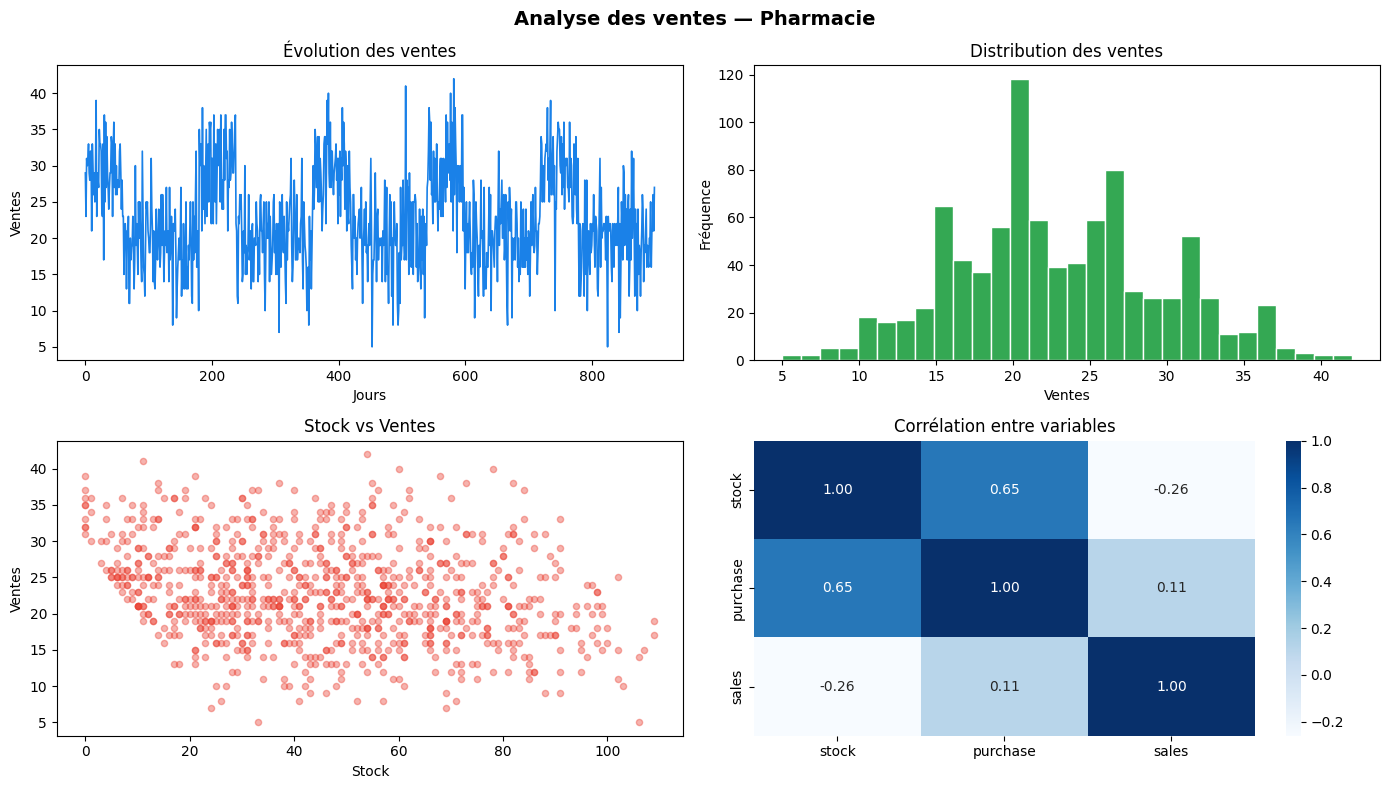

  Graphique sauvegardé : graphiques_exploration.png ✓


In [61]:
# ── 1.6  Graphiques ─────────────────────────────────────────────────────────
print("\n" + "=" * 150)
print("  1.5  GRAPHIQUES")
print("=" * 150)

fig, axes = plt.subplots(2, 2, figsize=(14, 8)) # En écran partagé
fig.suptitle("Analyse des ventes — Pharmacie", fontsize=14, fontweight="bold")

# Graphique 1 : évolution des ventes
axes[0, 0].plot(data["sales"], color="#1a81e8", linewidth=1.2)
axes[0, 0].set_title("Évolution des ventes")
axes[0, 0].set_xlabel("Jours")
axes[0, 0].set_ylabel("Ventes")

# Graphique 2 : distribution des ventes
axes[0, 1].hist(data["sales"], bins=30, color="#34a853", edgecolor="white")
axes[0, 1].set_title("Distribution des ventes")
axes[0, 1].set_xlabel("Ventes")
axes[0, 1].set_ylabel("Fréquence")

# Graphique 3 : stock vs ventes
axes[1, 0].scatter(data["stock"], data["sales"], alpha=0.4, color="#ea4335", s=20)
axes[1, 0].set_title("Stock vs Ventes")
axes[1, 0].set_xlabel("Stock")
axes[1, 0].set_ylabel("Ventes")

# Graphique 4 : matrice de corrélation
corr = data[["stock", "purchase", "sales"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=axes[1, 1])
axes[1, 1].set_title("Corrélation entre variables")

plt.tight_layout()
plt.savefig("graphiques_exploration.png", dpi=150)
plt.show()
print("  Graphique sauvegardé : graphiques_exploration.png ✓")

 Objectif : lire le CSV, afficher les infos de base,nettoyer les données, visualiser les ventes